# ACC102 Mini Assignment - Track 2
# Name: Yicen.Lian
# Student ID: 2468991
# Global Market Opportunity Analysis with Python

## 1. Problem Definition and Intended User

**Analytical problem:** Which countries combined **large market size** and **strong income growth** in the latest snapshot of this dataset, and how do continent-level patterns differ?

**Intended user:** This project is designed for **international business students and beginner market analysts** who need a simple data product to compare countries before discussing market entry or expansion ideas.

## 2. Dataset

- **Source:** Plotly Express built-in Gapminder dataset (country-level development indicators based on Gapminder)
- **Access date:** 20 April 2026
- **Main fields used:** `country`, `continent`, `year`, `lifeExp`, `pop`, `gdpPercap`
- **Business relevance:** The dataset provides a clear starting point for comparing **market scale**, **income level**, and **growth**, which are useful for business and economics discussion.

## 3. Workflow Overview

This notebook follows a simple product-oriented workflow:

1. Load and inspect the dataset  
2. Clean and prepare the core variables  
3. Compare continents in 2007  
4. Identify the largest markets in 2007  
5. Measure GDP per capita growth from 1997 to 2007  
6. Highlight countries that combine **scale + growth**  
7. Summarise findings for a non-technical user


## 4. Load Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 5. Load the Data

In [2]:
df = pd.read_csv('data/gapminder_clean.csv')
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,total_gdp_usd,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.80,8425333,779.45,"6,567,086,329.95",AFG,4
1,Afghanistan,Asia,1957,30.33,9240934,820.85,"7,585,448,670.23",AFG,4
2,Afghanistan,Asia,1962,32.00,10267083,853.10,"8,758,855,796.93",AFG,4
3,Afghanistan,Asia,1967,34.02,11537966,836.20,"9,648,014,149.85",AFG,4
4,Afghanistan,Asia,1972,36.09,13079460,739.98,"9,678,553,274.07",AFG,4


## 6. Inspect the Data

In [3]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nMissing values:')
print(df.isna().sum())

Shape: (1704, 9)

Columns: ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap', 'total_gdp_usd', 'iso_alpha', 'iso_num']

Missing values:
country          0
continent        0
year             0
lifeExp          0
pop              0
gdpPercap        0
total_gdp_usd    0
iso_alpha        0
iso_num          0
dtype: int64


## 7. Clean and Prepare the Data

In [4]:
# Keep the core analytical columns
df = df[['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap', 'total_gdp_usd']].copy()

# Basic cleaning
df = df.dropna()
df['country'] = df['country'].str.strip()
df['continent'] = df['continent'].str.strip()
df['year'] = df['year'].astype(int)
df['pop'] = df['pop'].astype(int)

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (1704, 7)


,country,continent,year,lifeExp,pop,gdpPercap,total_gdp_usd
0,Afghanistan,Asia,1952,28.80,8425333,779.45,"6,567,086,329.95"
1,Afghanistan,Asia,1957,30.33,9240934,820.85,"7,585,448,670.23"
2,Afghanistan,Asia,1962,32.00,10267083,853.10,"8,758,855,796.93"
3,Afghanistan,Asia,1967,34.02,11537966,836.20,"9,648,014,149.85"
4,Afghanistan,Asia,1972,36.09,13079460,739.98,"9,678,553,274.07"


## 8. Continent-Level Snapshot in 2007

In [5]:
# Latest year in the dataset
latest_year = df['year'].max()
latest = df[df['year'] == latest_year].copy()
print('Latest year used in this project:', latest_year)

continent_summary = (
    latest.groupby('continent')
    .agg(
        countries=('country', 'count'),
        avg_gdp_per_capita=('gdpPercap', 'mean'),
        avg_life_expectancy=('lifeExp', 'mean'),
        total_population=('pop', 'sum'),
        total_gdp=('total_gdp_usd', 'sum')
    )
    .sort_values('avg_gdp_per_capita', ascending=False)
    .reset_index()
)

continent_summary

Latest year used in this project: 2007


,continent,countries,avg_gdp_per_capita,avg_life_expectancy,total_population,total_gdp
0,Oceania,2,"29,810.19",80.72,24549947,"807,314,089,023.30"
1,Europe,30,"25,054.48",77.65,586098529,"14,795,499,331,554.99"
2,Asia,33,"12,473.03",70.73,3811953827,"20,707,949,957,614.86"
3,Americas,25,"11,003.03",73.61,898871184,"19,418,085,651,710.10"
4,Africa,52,"3,089.03",54.81,929539692,"2,380,485,684,001.31"


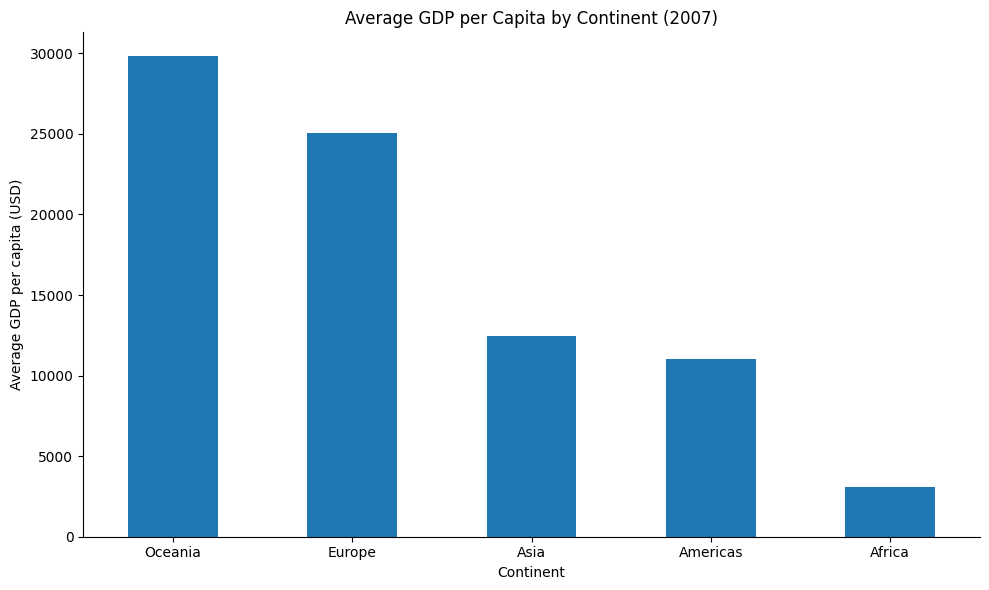

In [6]:
fig, ax = plt.subplots()
continent_summary.plot(
    kind='bar',
    x='continent',
    y='avg_gdp_per_capita',
    legend=False,
    ax=ax
)
ax.set_title('Average GDP per Capita by Continent (2007)')
ax.set_xlabel('Continent')
ax.set_ylabel('Average GDP per capita (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/continent_avg_gdp_per_capita_2007.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. The Largest Markets in 2007

In [7]:
top_markets = (
    latest.sort_values('total_gdp_usd', ascending=False)
    [['country', 'continent', 'pop', 'gdpPercap', 'total_gdp_usd']]
    .head(10)
    .copy()
)

top_markets

,country,continent,pop,gdpPercap,total_gdp_usd
1619,United States,Americas,301139947,"42,951.65","12,934,458,535,084.99"
299,China,Asia,1318683096,"4,959.11","6,539,500,929,092.31"
803,Japan,Asia,127467972,"31,656.07","4,035,134,797,102.17"
707,India,Asia,1110396331,"2,452.21","2,722,925,438,772.82"
575,Germany,Europe,82400996,"32,170.37","2,650,870,893,900.92"
1607,United Kingdom,Europe,60776238,"33,203.26","2,017,969,309,929.46"
539,France,Europe,61083916,"30,470.02","1,861,227,940,621.40"
179,Brazil,Americas,190010647,"9,065.80","1,722,598,680,331.38"
779,Italy,Europe,58147733,"28,569.72","1,661,264,433,000.44"
995,Mexico,Americas,108700891,"11,977.57","1,301,973,070,171.29"


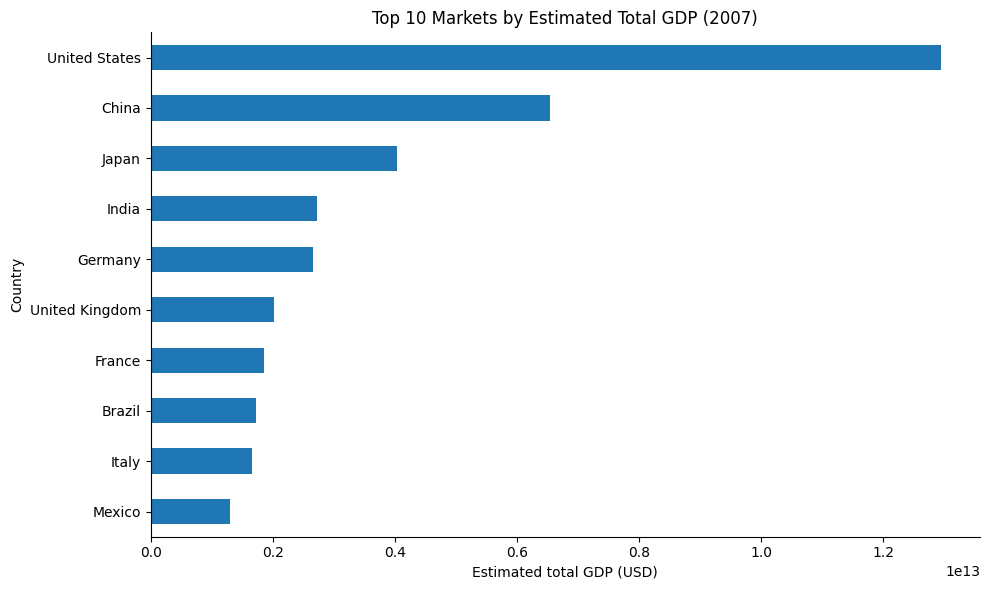

In [8]:
fig, ax = plt.subplots()
top_markets.sort_values('total_gdp_usd').plot(
    kind='barh',
    x='country',
    y='total_gdp_usd',
    legend=False,
    ax=ax
)
ax.set_title('Top 10 Markets by Estimated Total GDP (2007)')
ax.set_xlabel('Estimated total GDP (USD)')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('figures/top10_total_gdp_2007.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. GDP per Capita Growth from 1997 to 2007

In [9]:
base_1997 = (
    df[df['year'] == 1997][['country', 'gdpPercap', 'pop']]
    .rename(columns={'gdpPercap': 'gdp_per_capita_1997', 'pop': 'pop_1997'})
)

base_2007 = (
    df[df['year'] == 2007][['country', 'continent', 'gdpPercap', 'pop', 'total_gdp_usd']]
    .rename(columns={'gdpPercap': 'gdp_per_capita_2007', 'pop': 'pop_2007'})
)

growth = base_2007.merge(base_1997, on='country', how='inner')
growth['gdp_per_capita_growth_pct'] = (
    (growth['gdp_per_capita_2007'] / growth['gdp_per_capita_1997']) - 1
) * 100
growth['population_growth_pct'] = (
    (growth['pop_2007'] / growth['pop_1997']) - 1
) * 100

# Filter to larger markets so the result is more business-relevant
growth_large = growth[growth['pop_2007'] >= 20_000_000].copy()

fastest_growth = (
    growth_large.sort_values('gdp_per_capita_growth_pct', ascending=False)
    [['country', 'continent', 'pop_2007', 'gdp_per_capita_growth_pct', 'total_gdp_usd']]
    .head(10)
)

fastest_growth

,country,continent,pop_2007,gdp_per_capita_growth_pct,total_gdp_usd
87,Myanmar,Asia,47761980,127.47,"45,087,309,120.00"
24,China,Asia,1318683096,116.63,"6,539,500,929,092.31"
137,Vietnam,Asia,85262356,76.17,"208,174,556,559.05"
58,India,Asia,1110396331,68.10,"2,722,925,438,772.82"
120,Sudan,Africa,42292929,59.44,"110,062,906,753.49"
0,Afghanistan,Asia,31889923,53.39,"31,079,291,948.89"
102,Poland,Europe,38518241,51.48,"592,792,827,796.09"
119,Sri Lanka,Asia,20378239,49.00,"80,903,553,056.65"
106,Romania,Europe,22276056,47.12,"240,770,207,962.99"
70,"Korea, Rep.",Asia,49044790,45.98,"1,145,104,609,948.51"


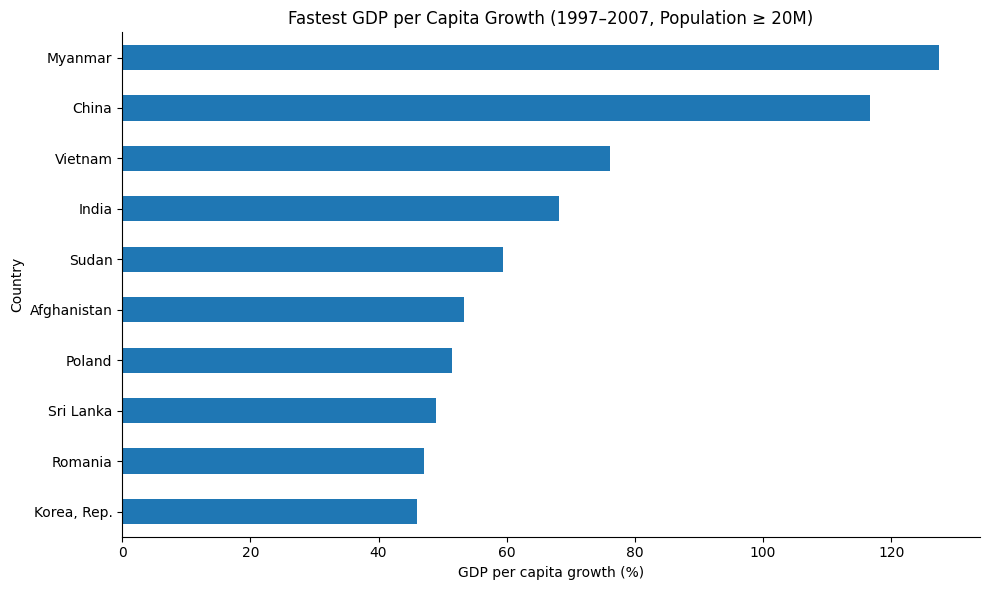

In [10]:
fig, ax = plt.subplots()
fastest_growth.sort_values('gdp_per_capita_growth_pct').plot(
    kind='barh',
    x='country',
    y='gdp_per_capita_growth_pct',
    legend=False,
    ax=ax
)
ax.set_title('Fastest GDP per Capita Growth (1997–2007, Population ≥ 20M)')
ax.set_xlabel('GDP per capita growth (%)')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('figures/fastest_growth_1997_2007.png', dpi=200, bbox_inches='tight')
plt.show()

## 11. A Simple Market Opportunity Matrix

In [11]:
# Opportunity matrix: countries in the top quartile for both size and growth
size_threshold = growth_large['total_gdp_usd'].quantile(0.75)
growth_threshold = growth_large['gdp_per_capita_growth_pct'].quantile(0.75)

growth_large['high_size'] = growth_large['total_gdp_usd'] >= size_threshold
growth_large['high_growth'] = growth_large['gdp_per_capita_growth_pct'] >= growth_threshold
growth_large['priority_market'] = np.where(
    growth_large['high_size'] & growth_large['high_growth'],
    'Yes',
    'No'
)

priority_markets = growth_large[growth_large['priority_market'] == 'Yes'][
    ['country', 'continent', 'total_gdp_usd', 'gdp_per_capita_growth_pct', 'pop_2007']
].sort_values('total_gdp_usd', ascending=False)

priority_markets

,country,continent,total_gdp_usd,gdp_per_capita_growth_pct,pop_2007
24,China,Asia,"6,539,500,929,092.31",116.63,1318683096
58,India,Asia,"2,722,925,438,772.82",68.10,1110396331
70,"Korea, Rep.",Asia,"1,145,104,609,948.51",45.98,49044790


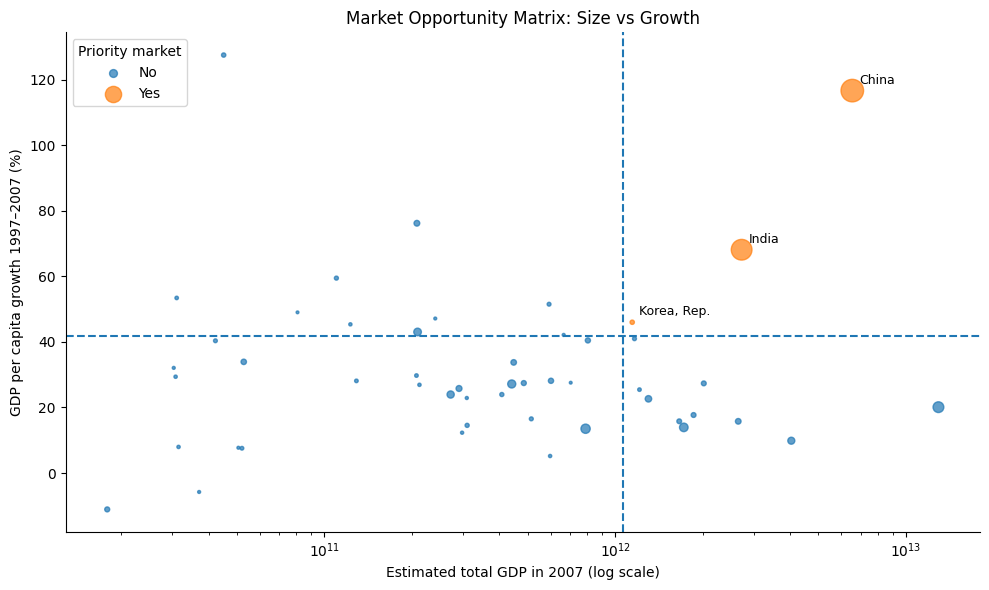

In [12]:
fig, ax = plt.subplots()
for label, subset in growth_large.groupby('priority_market'):
    ax.scatter(
        subset['total_gdp_usd'],
        subset['gdp_per_capita_growth_pct'],
        s=subset['pop_2007'] / 5_000_000,
        alpha=0.7,
        label=label
    )

for _, row in priority_markets.iterrows():
    ax.annotate(
        row['country'],
        (row['total_gdp_usd'], row['gdp_per_capita_growth_pct']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

ax.axvline(size_threshold, linestyle='--')
ax.axhline(growth_threshold, linestyle='--')
ax.set_xscale('log')
ax.set_title('Market Opportunity Matrix: Size vs Growth')
ax.set_xlabel('Estimated total GDP in 2007 (log scale)')
ax.set_ylabel('GDP per capita growth 1997–2007 (%)')
ax.legend(title='Priority market')
plt.tight_layout()
plt.savefig('figures/market_opportunity_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Summary Table

In [13]:
key_findings = pd.DataFrame({
    'Finding': [
        'Highest average GDP per capita by continent in 2007',
        'Largest market in 2007 by estimated total GDP',
        'Fastest-growing large market (population >= 20M)',
        'Countries that combine both high size and high growth'
    ],
    'Result': [
        continent_summary.iloc[0]['continent'],
        top_markets.iloc[0]['country'],
        fastest_growth.iloc[0]['country'],
        ', '.join(priority_markets['country'].tolist())
    ]
})

key_findings

,Finding,Result
0,Highest average GDP per capita by continent in...,Oceania
1,Largest market in 2007 by estimated total GDP,United States
2,Fastest-growing large market (population >= 20M),Myanmar
3,Countries that combine both high size and high...,"China, India, Korea, Rep."


## 4. Final Interpretation

### Main Insights
- **Oceania** has the highest average GDP per capita in the 2007 snapshot, although it contains only two countries. Among the larger multi-country regions, **Europe** also performs strongly on purchasing power.
- The **United States** is the largest market by estimated total GDP in 2007.
- **China** and **India** stand out because they combine very large population size with strong GDP per capita growth.
- Using a simple size-growth screen, **China, India, and Korea, Rep.** appear as the strongest priority markets in this dataset.

### Why this matters for the intended user
A beginner market analyst should not look only at income level or only at population. A country may be rich but slow-growing, or fast-growing but still relatively low-income. This notebook shows a simple Python workflow for combining these dimensions into a more useful decision support view.

### Limitations
- The dataset ends in **2007**, so it is useful for learning but not for making real-world investment decisions today.
- Estimated total GDP is calculated here as `population × GDP per capita`, which is simple but still a rough measure.
- This project does not include industry-level, policy, exchange rate, or risk variables.

### Next Step
A stronger future version could replace this dataset with more recent **World Bank** or **IMF** indicators and then deploy the analysis as a small dashboard.
